# BUS964 Team 3 — 구매 주기 분류 모델
**Step 3: Purchase Cycle Prediction (Classification)**  
오동환 · 김시철 · 이시윤 | 2026

## ⚙️ 설치 안내 (최초 1회만)
```bash
conda install -c conda-forge lightgbm xgboost imbalanced-learn -y
```

In [1]:
# ============================================================
# Cell 1 : 라이브러리 임포트
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (맥OS 기준)
import matplotlib.font_manager as fm
import platform

if platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지 (이것도 같이 설정 안 하면 '-' 가 □ 로 나옴)
plt.rcParams['axes.unicode_minus'] = False

# Sklearn 기본
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,   # LightGBM과 거의 동일한 sklearn 내장 모델
    VotingClassifier
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Imbalanced-learn (SMOTE)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print("✅ imbalanced-learn (SMOTE) 사용 가능")
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️  imbalanced-learn 미설치 → class_weight='balanced' 방식으로 대체")

# XGBoost / LightGBM (선택적)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("✅ XGBoost 사용 가능")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️  XGBoost 미설치 → 스킵")

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print("✅ LightGBM 사용 가능")
except ImportError:
    LGBM_AVAILABLE = False
    print("⚠️  LightGBM 미설치 → HistGradientBoosting으로 대체")

print("\n모든 라이브러리 로드 완료!")

✅ imbalanced-learn (SMOTE) 사용 가능
✅ XGBoost 사용 가능
✅ LightGBM 사용 가능

모든 라이브러리 로드 완료!


In [2]:
# ============================================================
# Cell 2 : 데이터 로드 & 전처리 (기존 방식 동일하게 유지)
# ============================================================

# ▶ 파일 경로 수정하세요
FILE_PATH = '/Users/siyun._.lee/KU/KU BUS 964 (김배호)/Team Project/Step 2_EDA/data.csv'

# ── 원본 데이터 로드 ──
raw = pd.read_csv(FILE_PATH, encoding='ISO-8859-1')
print(f"원본 거래 건수: {len(raw):,}")

# ── CustomerID 결측 제거 ──
raw = raw.dropna(subset=['CustomerID'])
raw['CustomerID'] = raw['CustomerID'].astype(int)
print(f"CustomerID 결측 제거 후: {len(raw):,}")

# ── 날짜·금액 컬럼 생성 ──
raw['InvoiceDate'] = pd.to_datetime(raw['InvoiceDate'])
raw['Date']        = raw['InvoiceDate'].dt.normalize()   # 시간 제거, 날짜만
raw['Amount']      = raw['Quantity'] * raw['UnitPrice']

# ── 일단위 합산 (환불·사은품 포함 — 기존 방침 유지) ──
daily = (
    raw
    .groupby(['CustomerID', 'Date'])
    .agg(Amount=('Amount', 'sum'), Quantity=('Quantity', 'sum'))
    .reset_index()
)
print(f"일단위 합산 후 행 수: {len(daily):,}")
print(f"유효 고객 수: {daily['CustomerID'].nunique():,}")
daily.head()

원본 거래 건수: 541,909
CustomerID 결측 제거 후: 406,829
일단위 합산 후 행 수: 19,296
유효 고객 수: 4,372


,CustomerID,Date,Amount,Quantity
0,12346,2011-01-18,0.00,0
1,12347,2010-12-07,711.79,319
2,12347,2011-01-26,475.39,315
3,12347,2011-04-07,636.25,483
4,12347,2011-06-09,382.52,196


In [3]:
# ============================================================
# Cell 3 : 예측 시나리오 설정
# ============================================================
# ▶ SCENARIO 를 바꾸면 두 시나리오 전환 가능
#
#   'DEC' : 11월까지 데이터로 학습 → 12월(1~9일) 구매여부 예측  (1차 시도)
#   'NOV' : 10월까지 데이터로 학습 → 11월 구매여부 예측         (검증 강화)

SCENARIO = 'NOV'   # ← 여기만 바꾸면 됨

if SCENARIO == 'NOV':
    FEATURE_CUTOFF = pd.Timestamp('2011-10-31')   # 피처 계산 기준일
    TARGET_START   = pd.Timestamp('2011-11-01')
    TARGET_END     = pd.Timestamp('2011-11-30')
    TARGET_LABEL   = '11월 구매 여부'
else:  # OCT
    FEATURE_CUTOFF = pd.Timestamp('2011-9-30')
    TARGET_START   = pd.Timestamp('2011-10-01')
    TARGET_END     = pd.Timestamp('2011-10-31')
    TARGET_LABEL   = '10월 구매 여부'

print(f"📋 시나리오    : {SCENARIO}")
print(f"   피처 학습  : ~ {FEATURE_CUTOFF.date()}")
print(f"   예측 타겟  : {TARGET_START.date()} ~ {TARGET_END.date()}")

📋 시나리오    : NOV
   피처 학습  : ~ 2011-10-31
   예측 타겟  : 2011-11-01 ~ 2011-11-30


In [4]:
# ============================================================
# Cell 4 : 피처 엔지니어링
# ============================================================
# 피처 기준일(FEATURE_CUTOFF) 이전 데이터만 사용
hist = daily[daily['Date'] <= FEATURE_CUTOFF].copy()

def build_features(hist_df, cutoff):
    """
    고객별 피처를 계산합니다.
    피처 설명:
      Recency          : 마지막 구매일 ~ 기준일 (일수) → 작을수록 최근 구매
      Frequency        : 총 구매 방문 횟수
      Total_Amount     : 누적 구매금액
      Avg_Amount       : 방문당 평균 구매금액
      Avg_Interval     : 평균 구매 주기(일) — 구매가 1번이면 999
      Wait_Ratio       : Recency ÷ Avg_Interval → 1에 가까울수록 구매 임박
      Freq_90d         : 최근 90일 내 구매 횟수 → 최근 활성도
      Amount_90d       : 최근 90일 구매금액
      Segment          : 총 구매금액 기준 고객 등급 (4=VIP ~ 1=AtRisk)
    """
    results = []
    cutoff_90 = cutoff - pd.Timedelta(days=90)

    for cid, grp in hist_df.groupby('CustomerID'):
        grp_sorted = grp.sort_values('Date')
        dates       = grp_sorted['Date'].tolist()
        amounts     = grp_sorted['Amount'].tolist()

        # 기본 RFM 지표
        recency   = (cutoff - dates[-1]).days
        frequency = len(dates)
        total_amt = sum(amounts)
        avg_amt   = total_amt / frequency if frequency > 0 else 0

        # 평균 구매 주기
        if len(dates) >= 2:
            intervals    = [(dates[i] - dates[i-1]).days for i in range(1, len(dates))]
            avg_interval = np.mean(intervals)
        else:
            avg_interval = 999  # 구매 1번뿐이면 주기 계산 불가

        # Wait_Ratio : 핵심 변수 (기존 모델과 동일 정의)
        wait_ratio = recency / avg_interval if avg_interval > 0 else 999

        # 최근 90일 활성도
        recent_mask = grp_sorted['Date'] >= cutoff_90
        freq_90d    = recent_mask.sum()
        amount_90d  = grp_sorted.loc[recent_mask, 'Amount'].sum()

        results.append({
            'CustomerID'  : cid,
            'Recency'     : recency,
            'Frequency'   : frequency,
            'Total_Amount': total_amt,
            'Avg_Amount'  : avg_amt,
            'Avg_Interval': avg_interval,
            'Wait_Ratio'  : wait_ratio,
            'Freq_90d'    : freq_90d,
            'Amount_90d'  : amount_90d,
        })

    feat_df = pd.DataFrame(results)

    # 고객 등급 (총 구매금액 분위수 기반 — 기존 세분화 방식 동일)
    q = feat_df['Total_Amount'].quantile([0.30, 0.70, 0.90])
    def assign_segment(amt):
        if amt >= q[0.90]: return 4  # VIP
        elif amt >= q[0.70]: return 3  # Growth
        elif amt >= q[0.30]: return 2  # General
        else: return 1  # At Risk
    feat_df['Segment'] = feat_df['Total_Amount'].apply(assign_segment)

    return feat_df

features = build_features(hist, FEATURE_CUTOFF)
print(f"피처 테이블 완성: {features.shape}")
print()
features.describe().round(2)

피처 테이블 완성: (4010, 10)



,CustomerID,Recency,Frequency,Total_Amount,Avg_Amount,Avg_Interval,Wait_Ratio,Freq_90d,Amount_90d,Segment
count,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00
mean,15284.19,93.07,3.95,1702.03,350.87,390.91,2.96,1.27,624.10,2.10
std,1718.71,94.43,5.85,7399.09,465.48,449.33,15.42,1.94,3214.19,0.94
min,12346.00,0.00,1.00,-4287.63,-4287.63,1.00,0.00,0.00,-561.60,1.00
25%,13803.25,19.00,1.00,270.07,158.96,36.00,0.12,0.00,0.00,1.00
50%,15276.50,50.00,2.00,603.40,256.59,86.00,0.32,1.00,206.23,2.00
75%,16753.75,151.75,4.00,1464.42,400.28,999.00,1.10,2.00,579.43,3.00
max,18287.00,334.00,119.00,242385.59,10767.95,999.00,333.00,41.00,106402.46,4.00


  11월 구매 여부 분포
  구매 O (1) : 1,390명  (34.7%)
  구매 X (0) : 2,620명  (65.3%)
  전체        : 4,010명
  불균형 비율 : 1 : 1.9
⚡ 중간 불균형 → class_weight 권장


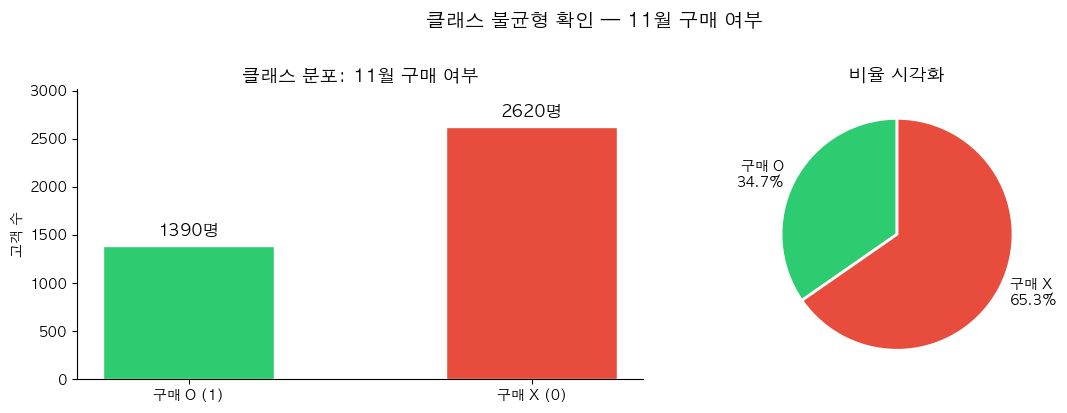

In [5]:
# ============================================================
# Cell 5 : 타겟 변수 생성 & 클래스 불균형 확인
# ============================================================

# 타겟 기간에 구매한 고객 집합
target_buyers = set(
    daily[
        (daily['Date'] >= TARGET_START) & (daily['Date'] <= TARGET_END)
    ]['CustomerID'].unique()
)

# 피처 테이블에 타겟 컬럼 추가
features['Target'] = features['CustomerID'].isin(target_buyers).astype(int)

# ── 클래스 불균형 확인 ──
n_pos  = features['Target'].sum()
n_neg  = len(features) - n_pos
n_total = len(features)
ratio   = n_pos / n_total

print(f"{'='*45}")
print(f"  {TARGET_LABEL} 분포")
print(f"{'='*45}")
print(f"  구매 O (1) : {n_pos:>5,}명  ({ratio*100:.1f}%)")
print(f"  구매 X (0) : {n_neg:>5,}명  ({(1-ratio)*100:.1f}%)")
print(f"  전체        : {n_total:>5,}명")
print(f"  불균형 비율 : 1 : {n_neg/n_pos:.1f}")
print(f"{'='*45}")

if ratio < 0.2:
    print("⚠️  심한 불균형 (< 20%) → SMOTE 또는 class_weight 필수!")
elif ratio < 0.4:
    print("⚡ 중간 불균형 → class_weight 권장")
else:
    print("✅ 양호한 클래스 비율")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 막대 그래프
ax = axes[0]
bars = ax.bar(['구매 O (1)', '구매 X (0)'], [n_pos, n_neg],
               color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%d명', padding=5, fontsize=12)
ax.set_title(f'클래스 분포: {TARGET_LABEL}', fontsize=13, fontweight='bold')
ax.set_ylabel('고객 수')
ax.set_ylim(0, n_neg * 1.15)
ax.spines[['top','right']].set_visible(False)

# 파이 그래프
ax2 = axes[1]
ax2.pie([n_pos, n_neg], labels=[f'구매 O\n{ratio*100:.1f}%', f'구매 X\n{(1-ratio)*100:.1f}%'],
        colors=['#2ecc71', '#e74c3c'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('비율 시각화', fontsize=13, fontweight='bold')

plt.suptitle(f'클래스 불균형 확인 — {TARGET_LABEL}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Cell 6 : Train / Test Split (Stratified 70 / 30)
# ============================================================
# stratify=y → 클래스 비율을 Train/Test에 동일하게 유지
# (불균형 데이터에서 test set에 0이 너무 많아지는 것 방지)

FEATURE_COLS = [
    'Recency', 'Frequency', 'Total_Amount', 'Avg_Amount',
    'Avg_Interval', 'Wait_Ratio', 'Freq_90d', 'Amount_90d', 'Segment'
]

X = features[FEATURE_COLS].values
y = features['Target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y          # ← 핵심: 클래스 비율 유지
)

print(f"Train: {len(X_train):,}명  |  Test: {len(X_test):,}명")
print()
print("[Train 클래스 비율]")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  클래스 {u}: {c:,}명 ({c/len(y_train)*100:.1f}%)")

print()
print("[Test 클래스 비율]")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  클래스 {u}: {c:,}명 ({c/len(y_test)*100:.1f}%)")
print()
print("✅ Stratified Split → Train/Test 클래스 비율 동일하게 유지됨")

Train: 2,807명  |  Test: 1,203명

[Train 클래스 비율]
  클래스 0: 1,834명 (65.3%)
  클래스 1: 973명 (34.7%)

[Test 클래스 비율]
  클래스 0: 786명 (65.3%)
  클래스 1: 417명 (34.7%)

✅ Stratified Split → Train/Test 클래스 비율 동일하게 유지됨


In [7]:
# ============================================================
# Cell 7 : 클래스 불균형 처리 — SMOTE (또는 class_weight)
# ============================================================
# SMOTE: 소수 클래스(구매 O) 데이터를 인공적으로 생성해 균형을 맞춤
# 규칙: SMOTE는 반드시 Training set에만 적용! Test set은 절대 건드리지 않음

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Train으로만 fit
X_test_scaled  = scaler.transform(X_test)        # Test는 transform만

if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
    print("[SMOTE 적용 후 Train 클래스 분포]")
    unique, counts = np.unique(y_train_res, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  클래스 {u}: {c:,}명 ({c/len(y_train_res)*100:.1f}%)")
    print("✅ SMOTE로 오버샘플링 완료")
else:
    # SMOTE 없으면 스케일된 데이터 그대로 사용
    # (각 모델에서 class_weight='balanced'로 불균형 처리)
    X_train_res, y_train_res = X_train_scaled, y_train
    print("⚠️  SMOTE 미사용 → class_weight='balanced'로 대체 처리")

print(f"\nTrain 최종 크기: {X_train_res.shape}")
print(f"Test  최종 크기: {X_test_scaled.shape}  (변경 없음)")

[SMOTE 적용 후 Train 클래스 분포]
  클래스 0: 1,834명 (50.0%)
  클래스 1: 1,834명 (50.0%)
✅ SMOTE로 오버샘플링 완료

Train 최종 크기: (3668, 9)
Test  최종 크기: (1203, 9)  (변경 없음)


In [8]:
# ============================================================
# Cell 8 : 모델 정의
# ============================================================
# 왜 이 모델들을 골랐는가?
#
# 1. LogisticRegression
#    → 베이스라인. 빠르고 해석 가능. 계수로 어떤 피처가 중요한지 바로 확인
#
# 2. RandomForestClassifier
#    → 팀 기존 코드와 연속성. 비선형 패턴 캡처. Overfitting에 강함
#      우리 데이터(4천명 소규모)에 안정적
#
# 3. HistGradientBoostingClassifier
#    → LightGBM의 sklearn 내장 버전. 속도·성능 모두 뛰어남
#      불균형 데이터에서 class_weight 지원. 소규모 데이터에서도 강력
#
# 4. XGBoostClassifier (설치된 경우)
#    → scale_pos_weight로 불균형 처리. 트리 기반 앙상블의 강자
#
# 5. LGBMClassifier (설치된 경우)
#    → is_unbalance=True로 자동 불균형 처리. 빠른 학습
#
# 6. VotingClassifier (앙상블)
#    → 상위 3개 모델 soft voting → 예측 안정성 향상

# 불균형 가중치 계산 (XGBoost용)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count
print(f"scale_pos_weight (XGBoost) = {scale_pos:.2f}")

# ── 모델 딕셔너리 ──
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',   # 불균형 처리
        max_iter=1000,
        random_state=42,
        C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',   # 불균형 처리
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    'HistGradient Boosting': HistGradientBoostingClassifier(
        max_iter=300,
        class_weight='balanced',   # 불균형 처리
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=300,
        scale_pos_weight=scale_pos,   # 불균형 처리
        learning_rate=0.05,
        max_depth=5,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

if LGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        is_unbalance=True,            # 불균형 처리
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

print(f"\n총 {len(models)}개 모델 준비 완료:")
for name in models:
    print(f"  • {name}")

scale_pos_weight (XGBoost) = 1.88

총 5개 모델 준비 완료:
  • Logistic Regression
  • Random Forest
  • HistGradient Boosting
  • XGBoost
  • LightGBM


In [9]:
# ============================================================
# Cell 9 : Cross Validation (Stratified K-Fold, k=5)
# ============================================================
# StratifiedKFold: 각 Fold의 클래스 비율을 원본과 동일하게 유지
# → 불균형 데이터에서 필수!
#
# 평가 지표:
#   ROC-AUC : 불균형 데이터 주요 지표 (Threshold 무관)
#   F1 (macro) : Precision·Recall의 조화평균
#   Accuracy : 참고용 (불균형에서 오해 유발 가능)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Cross Validation 실행 중...")
print(f"{'='*58}")
print(f"{'모델명':<25} {'ROC-AUC':>10} {'F1(macro)':>10} {'Accuracy':>10}")
print(f"{'-'*58}")

for name, model in models.items():
    cv_score = cross_validate(
        model,
        X_train_res, y_train_res,
        cv=cv,
        scoring=['roc_auc', 'f1_macro', 'accuracy'],
        n_jobs=-1
    )
    cv_results[name] = {
        'ROC-AUC'   : cv_score['test_roc_auc'],
        'F1_macro'  : cv_score['test_f1_macro'],
        'Accuracy'  : cv_score['test_accuracy'],
    }
    print(
        f"{name:<25}"
        f"  {cv_score['test_roc_auc'].mean():.4f}±{cv_score['test_roc_auc'].std():.3f}"
        f"  {cv_score['test_f1_macro'].mean():.4f}±{cv_score['test_f1_macro'].std():.3f}"
        f"  {cv_score['test_accuracy'].mean():.4f}±{cv_score['test_accuracy'].std():.3f}"
    )

print(f"{'='*58}")
print("\n📌 포맷: 평균 ± 표준편차")

Cross Validation 실행 중...
모델명                          ROC-AUC  F1(macro)   Accuracy
----------------------------------------------------------
Logistic Regression        0.7529±0.017  0.6916±0.020  0.6922±0.020
Random Forest              0.8103±0.017  0.7339±0.013  0.7339±0.013
HistGradient Boosting      0.8068±0.016  0.7305±0.014  0.7306±0.014
XGBoost                    0.8058±0.013  0.7055±0.015  0.7096±0.014
LightGBM                   0.8094±0.013  0.7294±0.015  0.7295±0.015

📌 포맷: 평균 ± 표준편차


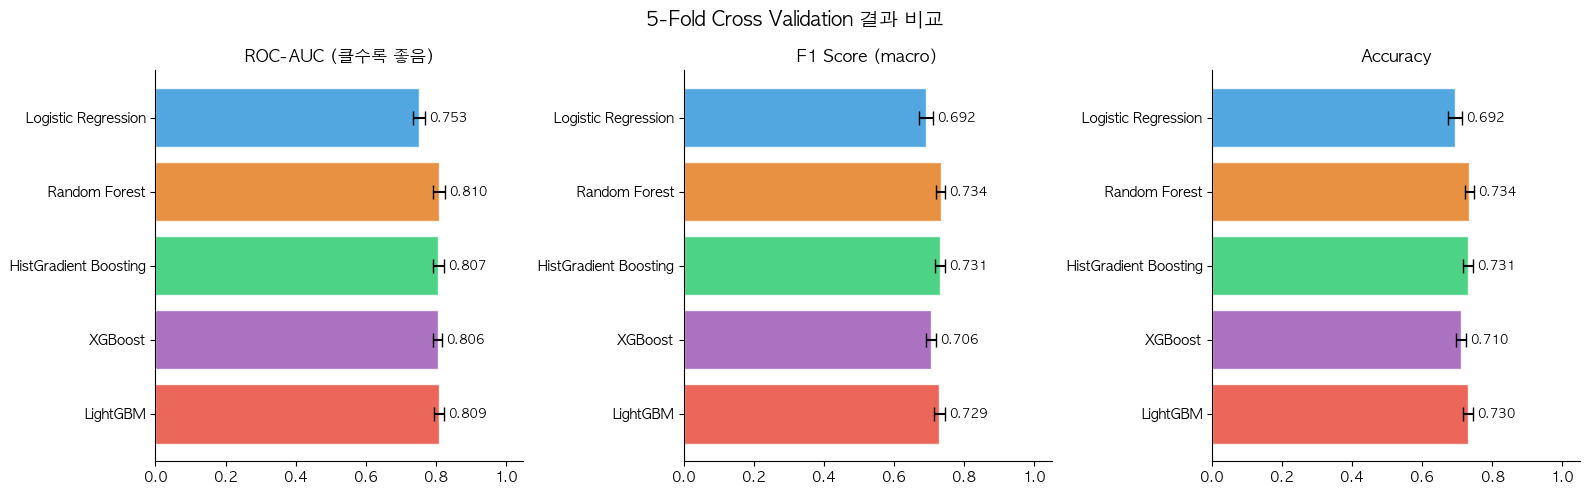


🏆 CV 기준 최고 모델 (ROC-AUC): Random Forest


In [10]:
# ============================================================
# Cell 10 : CV 결과 시각화
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['ROC-AUC', 'F1_macro', 'Accuracy']
titles  = ['ROC-AUC (클수록 좋음)', 'F1 Score (macro)', 'Accuracy']
colors  = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for ax, metric, title in zip(axes, metrics, titles):
    names  = list(cv_results.keys())
    means  = [cv_results[n][metric].mean() for n in names]
    stds   = [cv_results[n][metric].std()  for n in names]

    bars = ax.barh(names, means, xerr=stds,
                   color=colors[:len(names)], alpha=0.85,
                   edgecolor='white', capsize=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.bar_label(bars, labels=[f'{m:.3f}' for m in means],
                 padding=3, fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.invert_yaxis()

plt.suptitle('5-Fold Cross Validation 결과 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Best model by ROC-AUC
best_by_auc = max(cv_results, key=lambda n: cv_results[n]['ROC-AUC'].mean())
print(f"\n🏆 CV 기준 최고 모델 (ROC-AUC): {best_by_auc}")

In [11]:
# ============================================================
# Cell 11 : 앙상블 모델 (Soft Voting)
# ============================================================
# Soft Voting: 각 모델의 확률값을 평균 → 더 안정적인 예측
# 불균형 데이터에서 단일 모델보다 앙상블이 일반적으로 유리

# 앙상블에 포함할 모델 (ROC-AUC 상위 3개 자동 선택)
sorted_models = sorted(
    cv_results.items(),
    key=lambda x: x[1]['ROC-AUC'].mean(),
    reverse=True
)
top3_names = [name for name, _ in sorted_models[:3]]
print(f"앙상블 구성 모델 (상위 3개): {top3_names}")

ensemble_estimators = [(name, models[name]) for name in top3_names]

ensemble = VotingClassifier(
    estimators=ensemble_estimators,
    voting='soft',        # 확률값 평균
    n_jobs=-1
)

# 앙상블도 CV 평가
ensemble_cv = cross_validate(
    ensemble,
    X_train_res, y_train_res,
    cv=cv,
    scoring=['roc_auc', 'f1_macro', 'accuracy'],
    n_jobs=-1
)
print(f"\n앙상블 CV 결과:")
print(f"  ROC-AUC  : {ensemble_cv['test_roc_auc'].mean():.4f} ± {ensemble_cv['test_roc_auc'].std():.4f}")
print(f"  F1(macro): {ensemble_cv['test_f1_macro'].mean():.4f} ± {ensemble_cv['test_f1_macro'].std():.4f}")
print(f"  Accuracy : {ensemble_cv['test_accuracy'].mean():.4f} ± {ensemble_cv['test_accuracy'].std():.4f}")

cv_results['Ensemble (Voting)'] = {
    'ROC-AUC'  : ensemble_cv['test_roc_auc'],
    'F1_macro' : ensemble_cv['test_f1_macro'],
    'Accuracy' : ensemble_cv['test_accuracy'],
}

앙상블 구성 모델 (상위 3개): ['Random Forest', 'LightGBM', 'HistGradient Boosting']

앙상블 CV 결과:
  ROC-AUC  : 0.8141 ± 0.0156
  F1(macro): 0.7360 ± 0.0175
  Accuracy : 0.7361 ± 0.0175


In [12]:
# ============================================================
# Cell 12 : 모든 모델 Test Set 최종 평가
# ============================================================
all_models = dict(models)  # 복사
all_models['Ensemble (Voting)'] = ensemble

test_results = {}

for name, model in all_models.items():
    model.fit(X_train_res, y_train_res)          # 전체 Train으로 학습
    y_pred     = model.predict(X_test_scaled)     # Test 예측 (클래스)
    y_prob     = model.predict_proba(X_test_scaled)[:, 1]  # Test 예측 (확률)

    test_results[name] = {
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'roc_auc' : roc_auc_score(y_test, y_prob),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'f1_class1': f1_score(y_test, y_pred, average='binary'),  # 구매 O 클래스
    }

# 결과 테이블
print(f"{'='*65}")
print(f"{'모델명':<25} {'ROC-AUC':>10} {'F1(macro)':>10} {'F1(구매O)':>10}")
print(f"{'-'*65}")
for name, res in test_results.items():
    print(f"{name:<25}  {res['roc_auc']:>9.4f}  {res['f1_macro']:>9.4f}  {res['f1_class1']:>9.4f}")
print(f"{'='*65}")

best_model_name = max(test_results, key=lambda n: test_results[n]['roc_auc'])
print(f"\n🏆 Test 기준 최고 모델 (ROC-AUC): {best_model_name}")

모델명                          ROC-AUC  F1(macro)    F1(구매O)
-----------------------------------------------------------------
Logistic Regression           0.7142     0.6577     0.5672
Random Forest                 0.6912     0.6392     0.5366
HistGradient Boosting         0.6724     0.6399     0.5357
XGBoost                       0.6679     0.5875     0.5313
LightGBM                      0.6749     0.6373     0.5327
Ensemble (Voting)             0.6818     0.6431     0.5408

🏆 Test 기준 최고 모델 (ROC-AUC): Logistic Regression


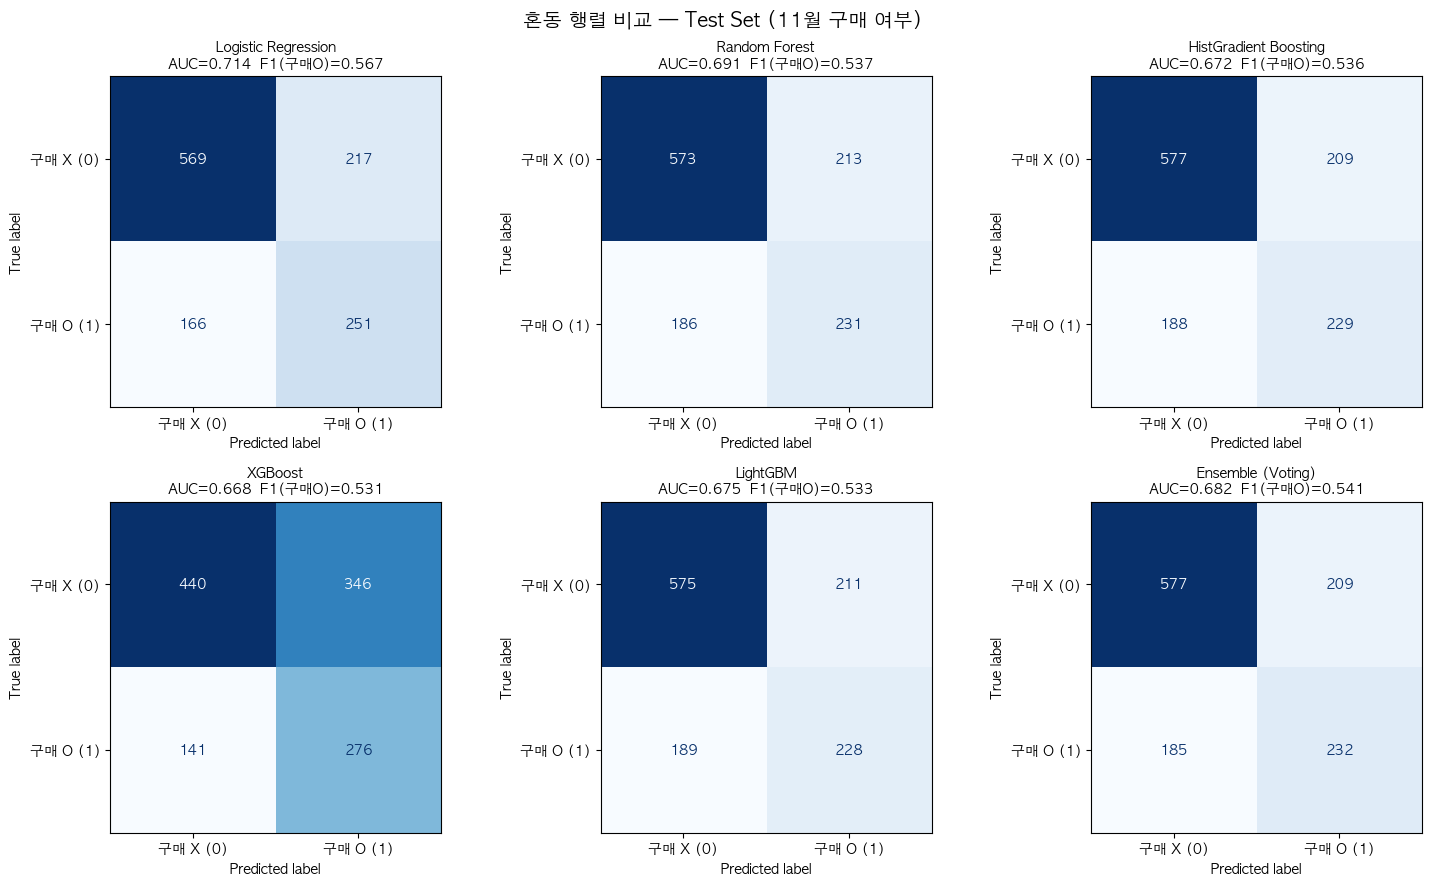

[읽는 법]
  왼쪽 위 (TN) : 실제 미구매 → 미구매 예측 ✅
  오른쪽 위 (FP): 실제 미구매 → 구매 예측  ❌ (False Alarm)
  왼쪽 아래 (FN): 실제 구매   → 미구매 예측 ❌ (놓친 고객)
  오른쪽 아래 (TP): 실제 구매 → 구매 예측  ✅


In [13]:
# ============================================================
# Cell 13 : 혼동 행렬 (Confusion Matrix) — 전체 모델
# ============================================================
n_models = len(all_models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
axes = axes.flatten()

for idx, (name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['구매 X (0)', '구매 O (1)'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(
        f"{name}\nAUC={res['roc_auc']:.3f}  F1(구매O)={res['f1_class1']:.3f}",
        fontsize=10, fontweight='bold'
    )

# 남은 축 숨기기
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'혼동 행렬 비교 — Test Set ({TARGET_LABEL})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("[읽는 법]")
print("  왼쪽 위 (TN) : 실제 미구매 → 미구매 예측 ✅")
print("  오른쪽 위 (FP): 실제 미구매 → 구매 예측  ❌ (False Alarm)")
print("  왼쪽 아래 (FN): 실제 구매   → 미구매 예측 ❌ (놓친 고객)")
print("  오른쪽 아래 (TP): 실제 구매 → 구매 예측  ✅")

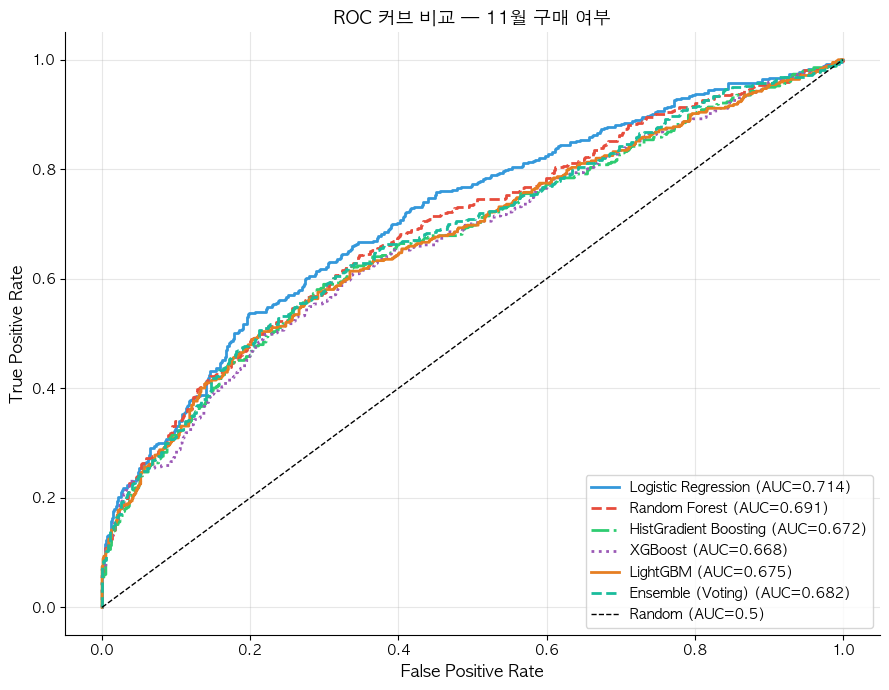

In [14]:
# ============================================================
# Cell 14 : ROC 커브 비교
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22', '#1abc9c']
linestyles = ['-', '--', '-.', ':', '-', '--']

for idx, (name, res) in enumerate(test_results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr,
            color=colors_roc[idx % len(colors_roc)],
            linestyle=linestyles[idx % len(linestyles)],
            lw=2,
            label=f"{name} (AUC={res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC 커브 비교 — {TARGET_LABEL}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

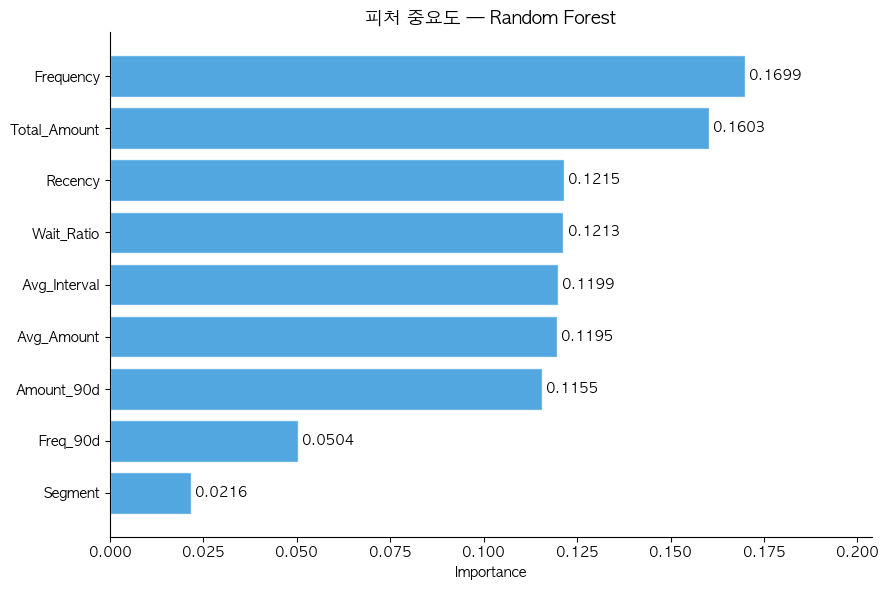


피처 중요도 해석:
  Frequency         : 0.1699
  Total_Amount      : 0.1603
  Recency           : 0.1215
  Wait_Ratio        : 0.1213
  Avg_Interval      : 0.1199
  Avg_Amount        : 0.1195
  Amount_90d        : 0.1155
  Freq_90d          : 0.0504
  Segment           : 0.0216


In [15]:
# ============================================================
# Cell 15 : 피처 중요도 — Best Model
# ============================================================
best_model = all_models[best_model_name]

# 피처 중요도 추출 가능한 모델 확인
importance_model = None
for candidate in ['Random Forest', 'HistGradient Boosting', 'LightGBM', 'XGBoost']:
    if candidate in all_models and hasattr(all_models[candidate], 'feature_importances_'):
        importance_model = all_models[candidate]
        importance_name  = candidate
        break

if importance_model is not None:
    importances = importance_model.feature_importances_
    feat_imp    = pd.DataFrame({
        'Feature'   : FEATURE_COLS,
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
                   color='#3498db', edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
    ax.set_title(f'피처 중요도 — {importance_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlim(0, feat_imp['Importance'].max() * 1.2)
    plt.tight_layout()
    plt.show()

    print("\n피처 중요도 해석:")
    for _, row in feat_imp.sort_values('Importance', ascending=False).iterrows():
        print(f"  {row['Feature']:<18}: {row['Importance']:.4f}")
else:
    print("피처 중요도를 직접 출력할 수 없는 모델입니다 (Logistic Regression의 경우 계수 참조).")

In [16]:
# ============================================================
# Cell 16 : Best Model 상세 리포트
# ============================================================
print(f"\n{'='*50}")
print(f"  🏆 최고 성능 모델: {best_model_name}")
print(f"{'='*50}")

y_pred_best = test_results[best_model_name]['y_pred']
print()
print(classification_report(
    y_test, y_pred_best,
    target_names=['구매 X (0)', '구매 O (1)'],
    digits=4
))
print(f"ROC-AUC: {test_results[best_model_name]['roc_auc']:.4f}")

print()
print("[마케팅 관점 해석]")
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pos    = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"  Precision(구매O): {precision_pos:.3f} → 구매 예측 고객 중 실제 구매 비율")
print(f"  Recall(구매O)   : {recall_pos:.3f}    → 실제 구매 고객 중 발굴한 비율")
print(f"  → 마케팅 쿠폰 발송 시 Precision 높을수록 비용 효율 좋음")
print(f"  → 이탈 방지 캠페인 시 Recall 높을수록 놓치는 고객 적음")


  🏆 최고 성능 모델: Logistic Regression

              precision    recall  f1-score   support

    구매 X (0)     0.7741    0.7239    0.7482       786
    구매 O (1)     0.5363    0.6019    0.5672       417

    accuracy                         0.6816      1203
   macro avg     0.6552    0.6629    0.6577      1203
weighted avg     0.6917    0.6816    0.6855      1203

ROC-AUC: 0.7142

[마케팅 관점 해석]
  Precision(구매O): 0.536 → 구매 예측 고객 중 실제 구매 비율
  Recall(구매O)   : 0.602    → 실제 구매 고객 중 발굴한 비율
  → 마케팅 쿠폰 발송 시 Precision 높을수록 비용 효율 좋음
  → 이탈 방지 캠페인 시 Recall 높을수록 놓치는 고객 적음


In [17]:
# ============================================================
# Cell 17 : 실제 검증 — 전체 고객 예측 vs 실제 11월 데이터
# ============================================================
# 모든 고객의 피처를 스케일링 → 베스트 모델로 예측
# → 실제 TARGET 기간 구매 여부와 비교

X_all   = features[FEATURE_COLS].values
X_all_s = scaler.transform(X_all)            # Train으로 fit된 scaler 재사용

y_prob_all = best_model.predict_proba(X_all_s)[:, 1]
y_pred_all = best_model.predict(X_all_s)

# 결과 테이블 생성
pred_df = features[['CustomerID', 'Recency', 'Frequency',
                     'Total_Amount', 'Wait_Ratio', 'Segment', 'Target']].copy()
pred_df['Pred_Prob']  = y_prob_all       # 구매 확률
pred_df['Pred_Label'] = y_pred_all       # 예측 (0/1)

# 전체 고객 대상 평가
full_auc = roc_auc_score(pred_df['Target'], pred_df['Pred_Prob'])
full_f1  = f1_score(pred_df['Target'], pred_df['Pred_Label'], average='binary')

print(f"[전체 고객 예측 vs 실제 {TARGET_LABEL}]")
print(f"  전체 고객 수 : {len(pred_df):,}명")
print(f"  실제 구매 O  : {pred_df['Target'].sum():,}명")
print(f"  예측 구매 O  : {pred_df['Pred_Label'].sum():,}명")
print(f"  ROC-AUC     : {full_auc:.4f}")
print(f"  F1 (구매O)  : {full_f1:.4f}")

# 구매 확률 상위 고객 미리보기
print("\n구매 확률 상위 10명:")
display(
    pred_df.sort_values('Pred_Prob', ascending=False)
    .head(10)
    [['CustomerID', 'Pred_Prob', 'Target', 'Recency', 'Wait_Ratio', 'Segment']]
    .assign(Pred_Prob=lambda x: x['Pred_Prob'].round(4))
    .reset_index(drop=True)
)

[전체 고객 예측 vs 실제 11월 구매 여부]
  전체 고객 수 : 4,010명
  실제 구매 O  : 1,390명
  예측 구매 O  : 1,611명
  ROC-AUC     : 0.7450
  F1 (구매O)  : 0.5978

구매 확률 상위 10명:


,CustomerID,Pred_Prob,Target,Recency,Wait_Ratio,Segment
0,14646,1.0,1,4,0.488746,4
1,14911,1.0,1,0,0.000000,4
2,18102,1.0,1,10,0.691824,4
3,17450,1.0,1,0,0.000000,4
4,17841,1.0,1,0,0.000000,4
5,14156,1.0,1,7,0.880368,4
6,12748,1.0,1,3,0.815710,4
7,15311,1.0,1,3,0.697885,4
8,13089,1.0,1,1,0.221884,4
9,16029,1.0,1,5,0.653495,4


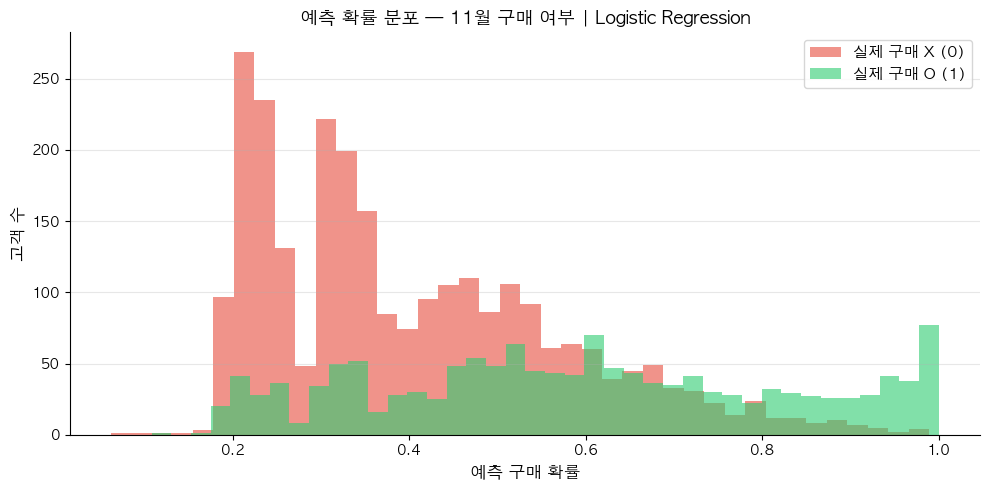

[해석]
  두 분포가 잘 분리될수록 모델 성능이 좋음
  초록(구매O) 분포가 오른쪽에, 빨강(구매X) 분포가 왼쪽에 몰려야 이상적


In [18]:
# ============================================================
# Cell 18 : 예측 확률 분포 — 실제 구매 O vs X 비교
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(pred_df.loc[pred_df['Target']==0, 'Pred_Prob'], bins=40,
        alpha=0.6, color='#e74c3c', label='실제 구매 X (0)')
ax.hist(pred_df.loc[pred_df['Target']==1, 'Pred_Prob'], bins=40,
        alpha=0.6, color='#2ecc71', label='실제 구매 O (1)')

ax.set_xlabel('예측 구매 확률', fontsize=12)
ax.set_ylabel('고객 수', fontsize=12)
ax.set_title(f'예측 확률 분포 — {TARGET_LABEL} | {best_model_name}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("[해석]")
print("  두 분포가 잘 분리될수록 모델 성능이 좋음")
print("  초록(구매O) 분포가 오른쪽에, 빨강(구매X) 분포가 왼쪽에 몰려야 이상적")

세그먼트별 예측 성능:
Segment_Name     고객수  실제 구매 O%  평균 예측 확률%  AUC
         VIP  401.00     72.32      84.70 0.82
      Growth  802.00     50.62      63.55 0.68
     General 1604.00     29.55      43.02 0.67
     At Risk 1203.00     18.29      28.52 0.55


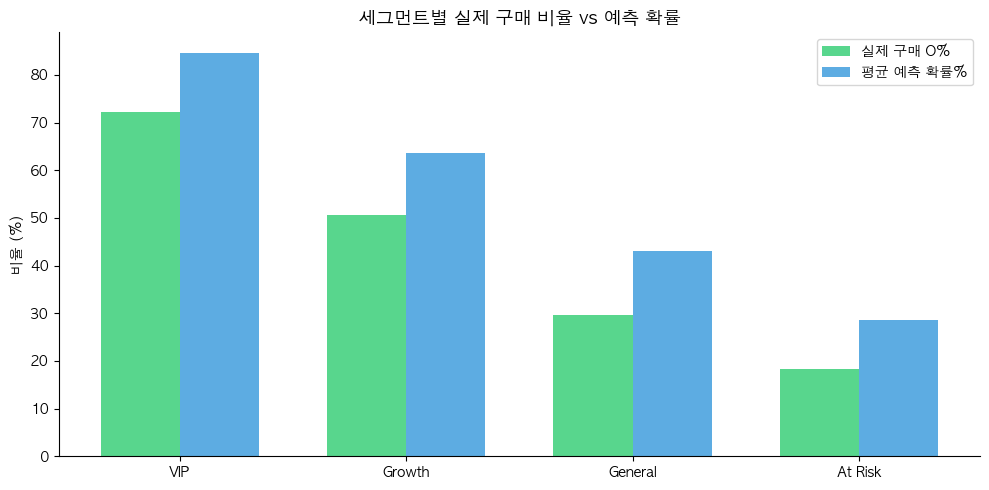

In [19]:
# ============================================================
# Cell 19 : 세그먼트별 예측 정확도 비교
# ============================================================
# 어떤 고객 등급에서 예측이 잘 맞는지 확인

seg_map = {4: 'VIP', 3: 'Growth', 2: 'General', 1: 'At Risk'}
pred_df['Segment_Name'] = pred_df['Segment'].map(seg_map)

seg_summary = pred_df.groupby('Segment_Name').apply(
    lambda g: pd.Series({
        '고객수'       : len(g),
        '실제 구매 O%' : g['Target'].mean() * 100,
        '평균 예측 확률%': g['Pred_Prob'].mean() * 100,
        'AUC'          : roc_auc_score(g['Target'], g['Pred_Prob'])
                         if g['Target'].nunique() > 1 else float('nan')
    })
).reset_index()

# 등급 순서 정렬
seg_order = ['VIP', 'Growth', 'General', 'At Risk']
seg_summary['Segment_Name'] = pd.Categorical(
    seg_summary['Segment_Name'], categories=seg_order, ordered=True
)
seg_summary = seg_summary.sort_values('Segment_Name')

print("세그먼트별 예측 성능:")
print(seg_summary.to_string(index=False, float_format='%.2f'))

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(seg_summary))
width = 0.35
ax.bar(x - width/2, seg_summary['실제 구매 O%'], width,
       label='실제 구매 O%', color='#2ecc71', alpha=0.8)
ax.bar(x + width/2, seg_summary['평균 예측 확률%'], width,
       label='평균 예측 확률%', color='#3498db', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(seg_summary['Segment_Name'])
ax.set_ylabel('비율 (%)')
ax.set_title('세그먼트별 실제 구매 비율 vs 예측 확률', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Cell 20 : 모델 요약 — 발표용 테이블
# ============================================================
summary_rows = []
for name, res in test_results.items():
    cv_auc = cv_results[name]['ROC-AUC'].mean() if name in cv_results else float('nan')
    summary_rows.append({
        '모델'         : name,
        'CV ROC-AUC'  : f"{cv_auc:.4f}",
        'Test ROC-AUC': f"{res['roc_auc']:.4f}",
        'F1 (구매O)'  : f"{res['f1_class1']:.4f}",
        'F1 (macro)'  : f"{res['f1_macro']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(f"\n{'='*70}")
print(f"  전체 모델 성능 요약 — {TARGET_LABEL} 예측")
print(f"{'='*70}")
print(summary_df.to_string(index=False))
print(f"{'='*70}")
print(f"\n📌 추천 모델  : {best_model_name}")
print(f"   Test AUC   : {test_results[best_model_name]['roc_auc']:.4f}")
print(f"   F1(구매O)  : {test_results[best_model_name]['f1_class1']:.4f}")
print()
print("📌 모델 선택 기준:")
print("   • 불균형 데이터 → Accuracy 말고 ROC-AUC / F1 중심으로 판단")
print("   • 마케팅 활용 목적 → Recall(구매O) 높을수록 유리")
print("   • 비용 효율 목적  → Precision(구매O) 높을수록 유리")


  전체 모델 성능 요약 — 11월 구매 여부 예측
                   모델 CV ROC-AUC Test ROC-AUC F1 (구매O) F1 (macro)
  Logistic Regression     0.7529       0.7142   0.5672     0.6577
        Random Forest     0.8103       0.6912   0.5366     0.6392
HistGradient Boosting     0.8068       0.6724   0.5357     0.6399
              XGBoost     0.8058       0.6679   0.5313     0.5875
             LightGBM     0.8094       0.6749   0.5327     0.6373
    Ensemble (Voting)     0.8141       0.6818   0.5408     0.6431

📌 추천 모델  : Logistic Regression
   Test AUC   : 0.7142
   F1(구매O)  : 0.5672

📌 모델 선택 기준:
   • 불균형 데이터 → Accuracy 말고 ROC-AUC / F1 중심으로 판단
   • 마케팅 활용 목적 → Recall(구매O) 높을수록 유리
   • 비용 효율 목적  → Precision(구매O) 높을수록 유리
